# Credit Risk Modelling

Steps involved in data clearning for credit risk modelling with machine learning: 
- Gathering tha data 
- Data Quality/Data Cleaning 
- Developing the behaviourial scorecard (The machine learning/statistical model) 
- Using the model to predict scores (Credit rating)

The expectation will be for you to replicate the same adding important bits like :
- Doing extra exploratory data analysis and providing insights on any notable trends 
- Performing indepth data cleaning and providing explations on the steps and rationale behind the methodology used e.g when handling the missing values, why would you opt for deletion rather than imputation 
- Doing extra feature engineering and feature selction to improve the model performance. 
- Using alternative models and providing adequate justification for the same. 

## Libraries & Data import

In [39]:
# Data Exploration libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     # Visualization
import seaborn as sns               # Advanced Visualization
import missingno as mn

In [40]:
# Loading data 
Loan = pd.read_csv(r"./data/raw-data.csv")

Loan.head(2)

C:\Users\HP\AppData\Local\Temp\ipykernel_20800\1724087143.py:2: DtypeWarning: Columns (0: V10, 1: V13, 2: V14, 3: V15, 4: V16) have mixed types. Specify dtype option on import or set low_memory=False.
  Loan = pd.read_csv(r"./data/raw-data.csv")


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0


In [41]:
Loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 119528 entries, 0 to 119527
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      119528 non-null  int64  
 1   V2      119528 non-null  int64  
 2   V3      119528 non-null  int64  
 3   V4      85048 non-null   float64
 4   V5      85048 non-null   float64
 5   V6      85048 non-null   float64
 6   V7      85048 non-null   float64
 7   V8      85048 non-null   float64
 8   V9      85048 non-null   float64
 9   V10     85048 non-null   str    
 10  V11     85048 non-null   float64
 11  V12     85048 non-null   float64
 12  V13     85048 non-null   str    
 13  V14     85048 non-null   str    
 14  V15     84131 non-null   str    
 15  V16     85048 non-null   str    
 16  V17     85048 non-null   float64
 17  V18     119528 non-null  int64  
 18  V19     119528 non-null  int64  
 19  V20     119528 non-null  int64  
 20  V21     36626 non-null   float64
 21  V22     119528 non-nu

In [43]:
# From the dtypewarning, we can see that there are some columns that are not in the correct format. We will need to convert them to the correct format before we can do any analysis on them.

Loan = Loan.convert_dtypes()

Loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 119528 entries, 0 to 119527
Data columns (total 32 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      119528 non-null  Int64  
 1   V2      119528 non-null  Int64  
 2   V3      119528 non-null  Int64  
 3   V4      85048 non-null   Int64  
 4   V5      85048 non-null   Int64  
 5   V6      85048 non-null   Int64  
 6   V7      85048 non-null   Int64  
 7   V8      85048 non-null   Int64  
 8   V9      85048 non-null   Int64  
 9   V10     85048 non-null   string 
 10  V11     85048 non-null   Int64  
 11  V12     85048 non-null   Float64
 12  V13     85048 non-null   string 
 13  V14     85048 non-null   string 
 14  V15     84131 non-null   string 
 15  V16     85048 non-null   string 
 16  V17     85048 non-null   Int64  
 17  V18     119528 non-null  Int64  
 18  V19     119528 non-null  Int64  
 19  V20     119528 non-null  Int64  
 20  V21     36626 non-null   Int64  
 21  V22     119528 non-nu

In [46]:
#Renaming columns in the dataset with their correct names
Loan = Loan.rename(columns={
    'V1':  'Customer ID',
    'V2':  'Bounced First EMI',
    'V3':  'Bounced Count 12M',
    'V4':  'Max MOB',
    'V5':  'Total Bounce Count',
    'V6':  'EMI',
    'V7':  'Loan Amount',
    'V8':  'Tenure',
    'V9':  'Dealer Code',
    'V10': 'Product Code',
    'V11': 'Advance EMI Paid',
    'V12': 'Interest Rate',
    'V13': 'Gender',
    'V14': 'Employment Type',
    'V15': 'Resident Type',
    'V16': 'Date of Birth',
    'V17': 'Age at Loan',
    'V18': 'Total Loans',
    'V19': 'Secured Loans',
    'V20': 'Unsecured Loans',
    'V21': 'Max Live Loan Amount',
    'V22': 'New Loans 3M',
    'V23': 'Live Secured Amount',
    'V24': 'Live Unsecured Amount',
    'V25': 'Max TW Loan Amount',
    'V26': 'Months Since Last PL',
    'V27': 'Months Since First CD Loan',
    'V28': 'DPD 30 Days 6M',
    'V29': 'DPD 60 Days 6M',
    'V30': 'DPD 90 Days 3M',
    'V31': 'Tier',
    'V32': 'Default'})

Loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 119528 entries, 0 to 119527
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Customer ID                 119528 non-null  Int64  
 1   Bounced First EMI           119528 non-null  Int64  
 2   Bounced Count 12M           119528 non-null  Int64  
 3   Max MOB                     85048 non-null   Int64  
 4   Total Bounce Count          85048 non-null   Int64  
 5   EMI                         85048 non-null   Int64  
 6   Loan Amount                 85048 non-null   Int64  
 7   Tenure                      85048 non-null   Int64  
 8   Dealer Code                 85048 non-null   Int64  
 9   Product Code                85048 non-null   string 
 10  Advance EMI Paid            85048 non-null   Int64  
 11  Interest Rate               85048 non-null   Float64
 12  Gender                      85048 non-null   string 
 13  Employment Type          

## Basic EDA & Data Cleaning

### EDA

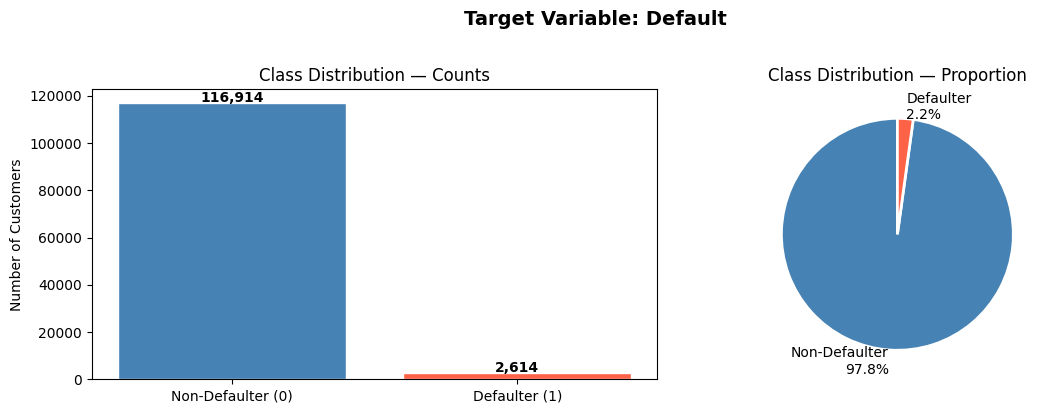

Imbalance ratio — Non-Default : Default = 44.7 : 1


In [ ]:
target_counts = Loan['Default'].value_counts()
target_pct    = Loan['Default'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Non-Defaulter (0)', 'Defaulter (1)'],
            target_counts.values,
            color=['steelblue', 'tomato'],
            edgecolor='white')
axes[0].set_title('Class Distribution — Counts')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart for proportion
axes[1].pie(target_pct.values,
            labels=[f'Non-Defaulter\n{target_pct.iloc[0]:.1f}%',
                    f'Defaulter\n{target_pct.iloc[1]:.1f}%'],
            colors=['steelblue', 'tomato'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Proportion')

plt.suptitle('Target Variable: Default', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Imbalance ratio — Non-Default : Default = {target_counts[0]/target_counts[1]:.1f} : 1')

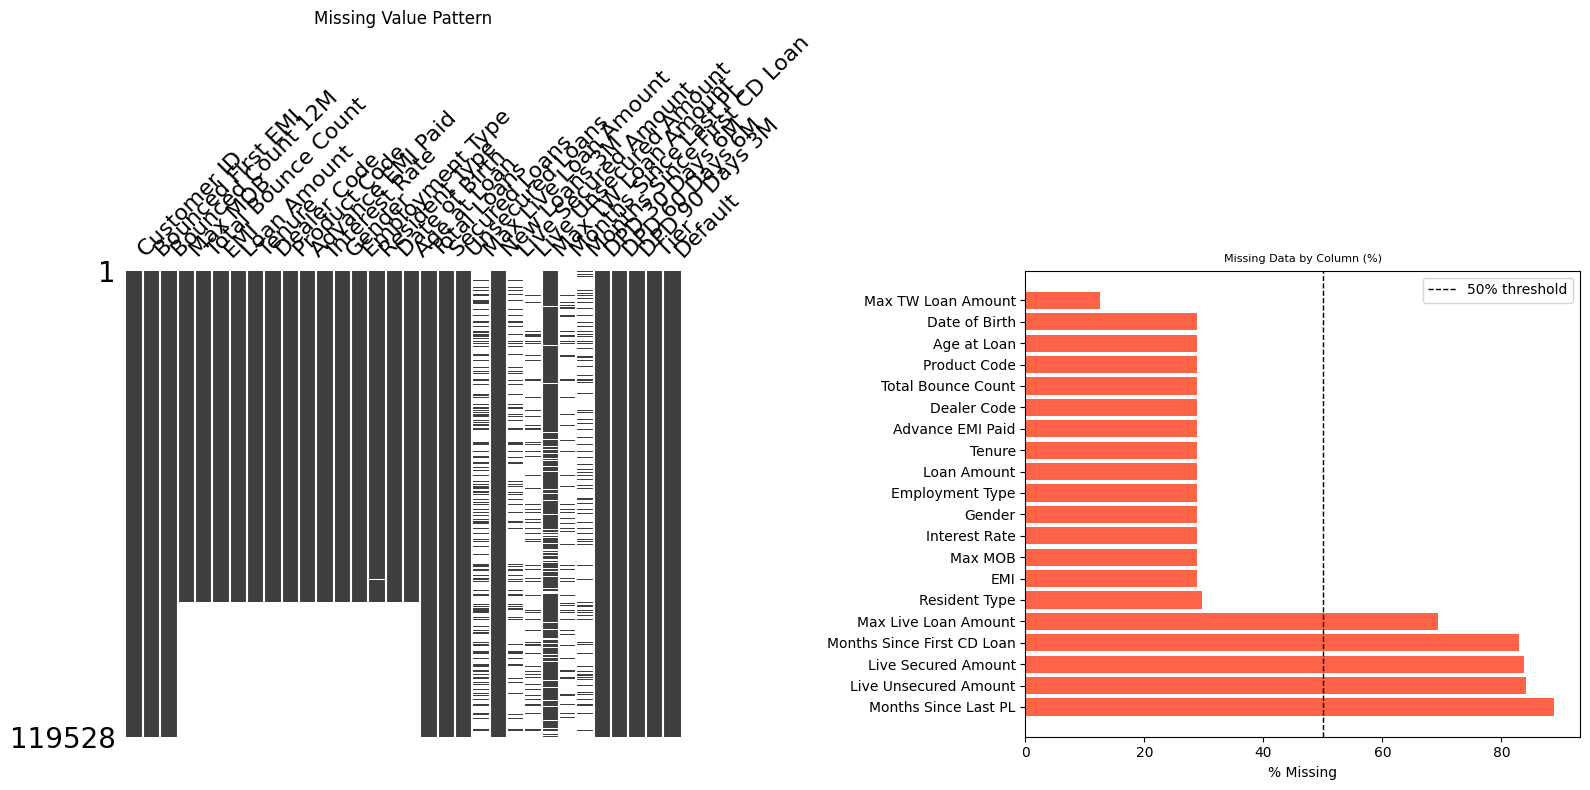

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

mn.matrix(Loan, ax=axes[0], sparkline=False)
axes[0].set_title('Missing Value Pattern', fontsize=12)

# Bar chart showing % missing per column
miss_pct = (Loan.isnull().sum() / len(Loan) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
axes[1].barh(miss_pct.index, miss_pct.values, color='tomato')
axes[1].set_xlabel('% Missing')
axes[1].set_title('Missing Data by Column (%)', fontsize=8)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

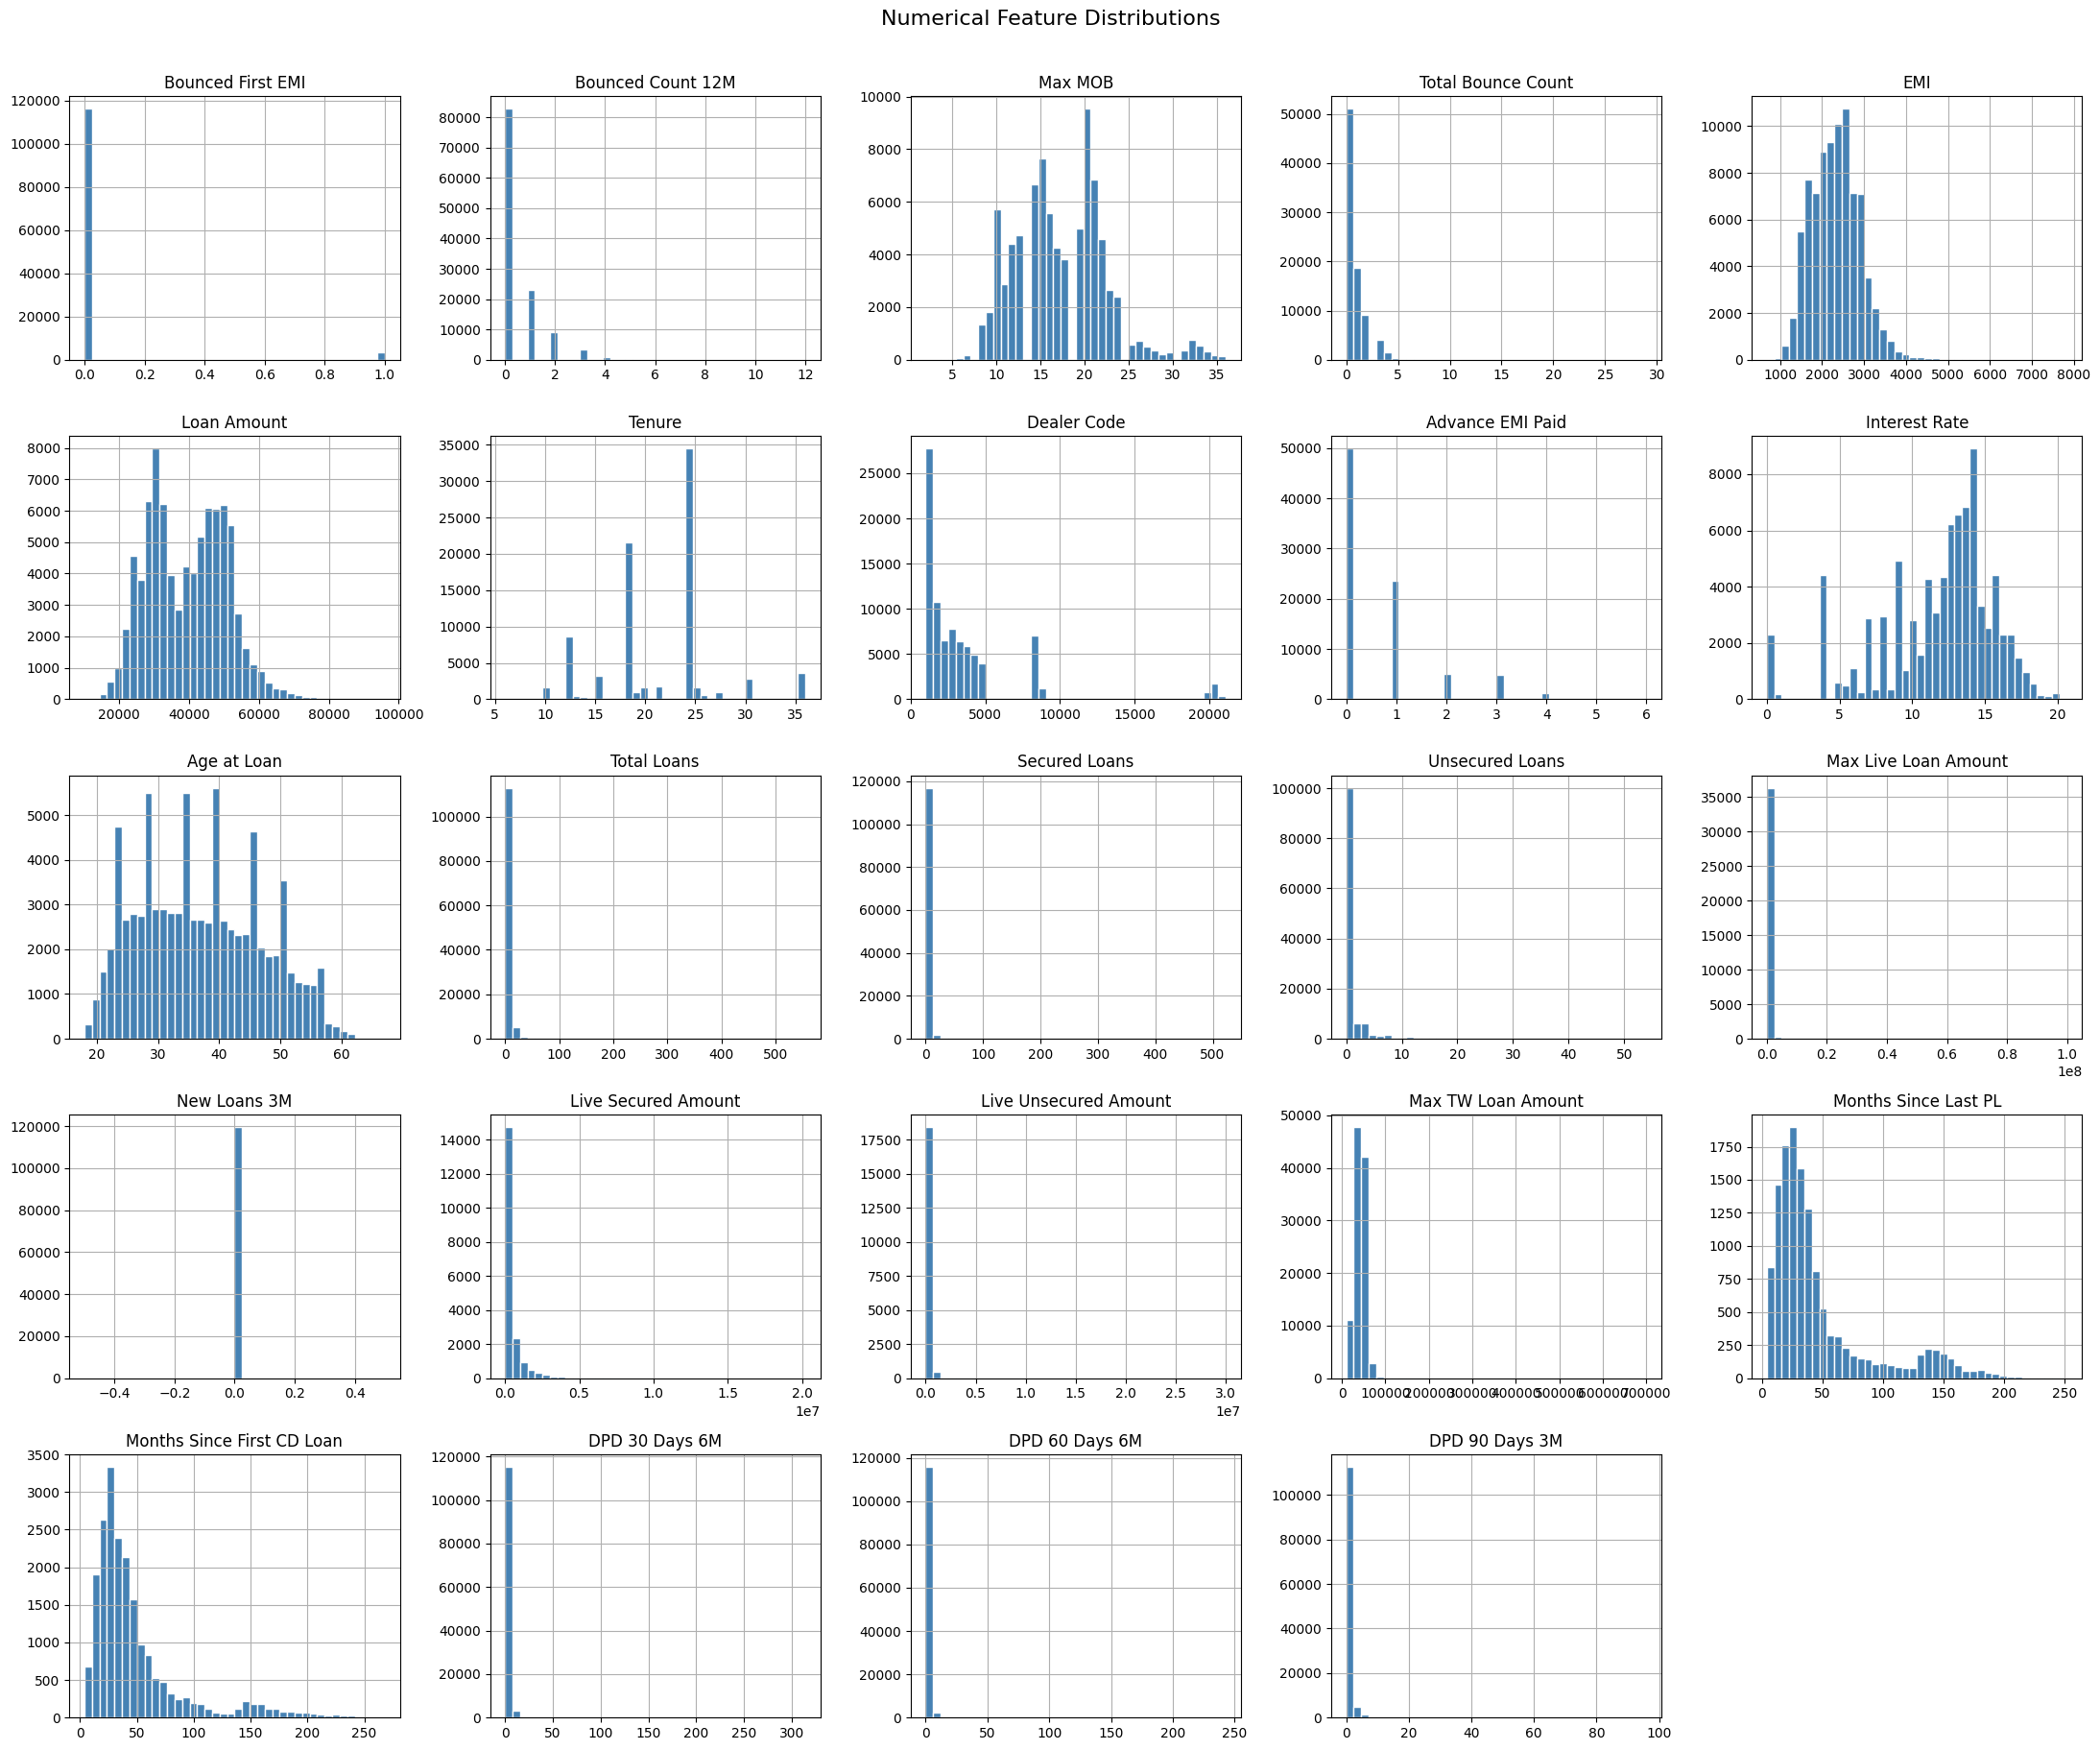

In [63]:
num_cols = Loan.select_dtypes(include=np.number).columns.drop('Customer ID').drop('Default')

Loan[num_cols].hist(figsize=(22, 18), bins=40, color='steelblue', edgecolor='white')
plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

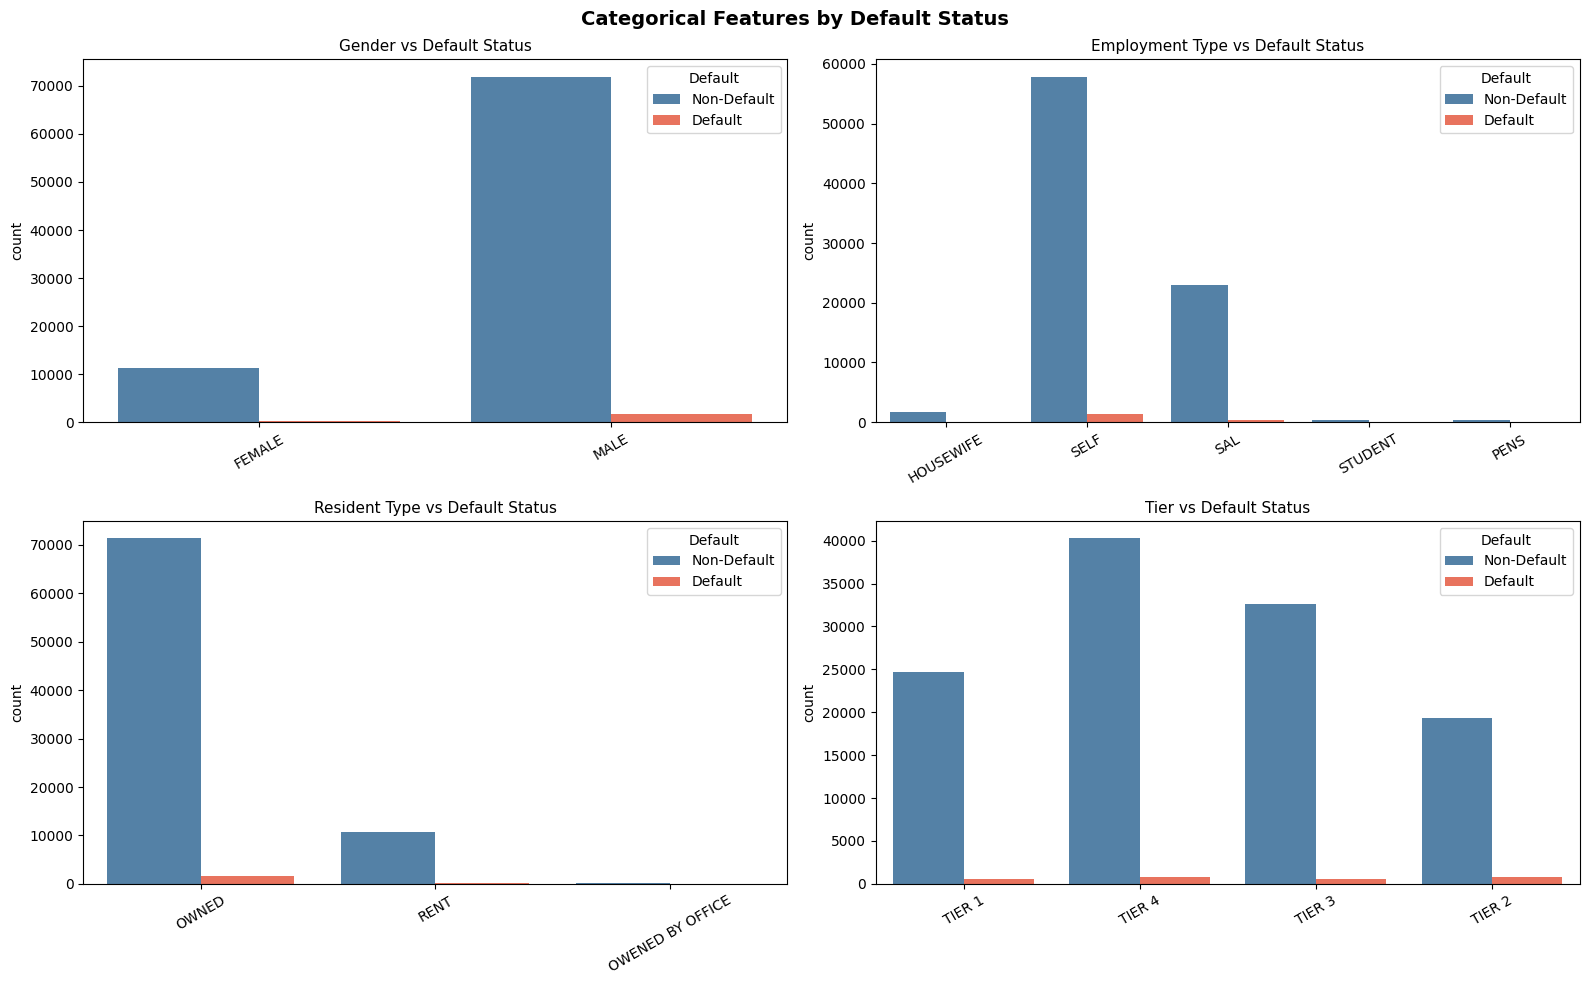

In [64]:
cat_cols = ['Gender', 'Employment Type', 'Resident Type', 'Tier']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Convert default label for readability
    plot_df = Loan[[col, 'Default']].copy()
    plot_df['Default'] = plot_df['Default'].map({0: 'Non-Default', 1: 'Default'})
    
    sns.countplot(
        data=plot_df,
        x=col,
        hue='Default',
        palette={'Non-Default': 'steelblue', 'Default': 'tomato'},
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs Default Status', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')

plt.suptitle('Categorical Features by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

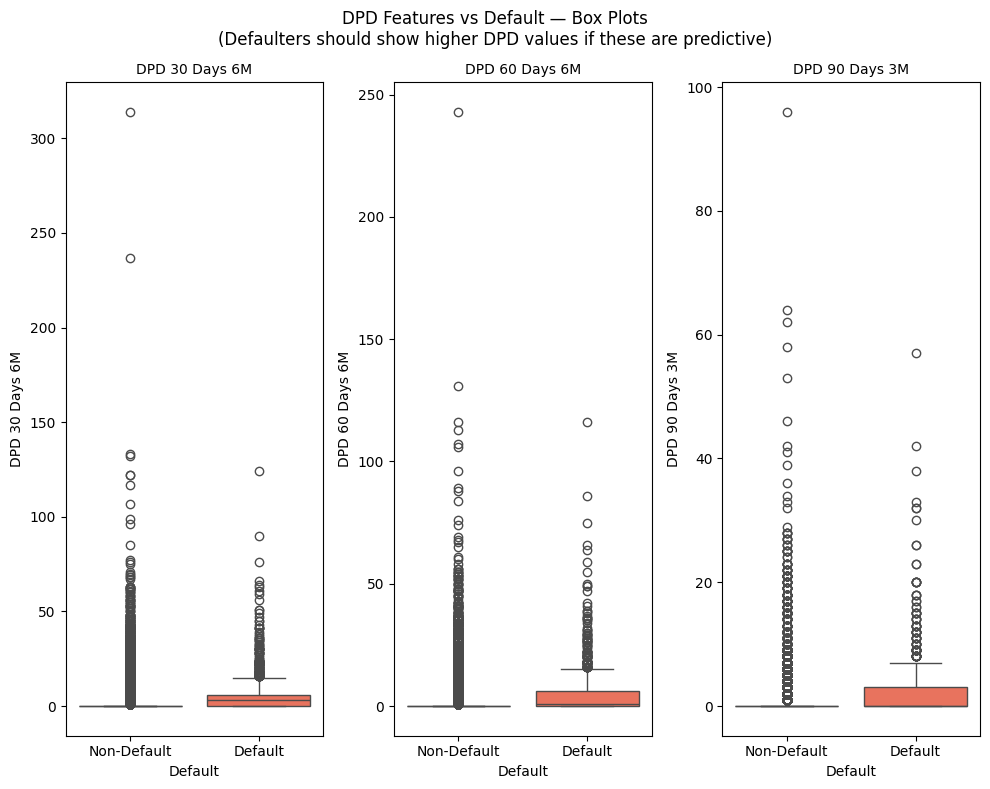

In [68]:
dpd_cols = ['DPD 30 Days 6M', 'DPD 60 Days 6M', 'DPD 90 Days 3M']

fig, axes = plt.subplots(1, 3, figsize=(10, 8))

for i, col in enumerate(dpd_cols):
    plot_df = Loan[[col, 'Default']].copy()
    plot_df['Default'] = plot_df['Default'].map({0: 'Non-Default', 1: 'Default'})
    
    sns.boxplot(
        data=plot_df,
        x='Default',
        y=col,
        palette={'Non-Default': 'steelblue', 'Default': 'tomato'},
        hue='Default',
        ax=axes[i]
    )
    axes[i].set_title(f'{col}', fontsize=10)

plt.suptitle('DPD Features vs Default — Box Plots\n'
             '(Defaulters should show higher DPD values if these are predictive)',
             fontsize=12)
plt.tight_layout()
plt.show()

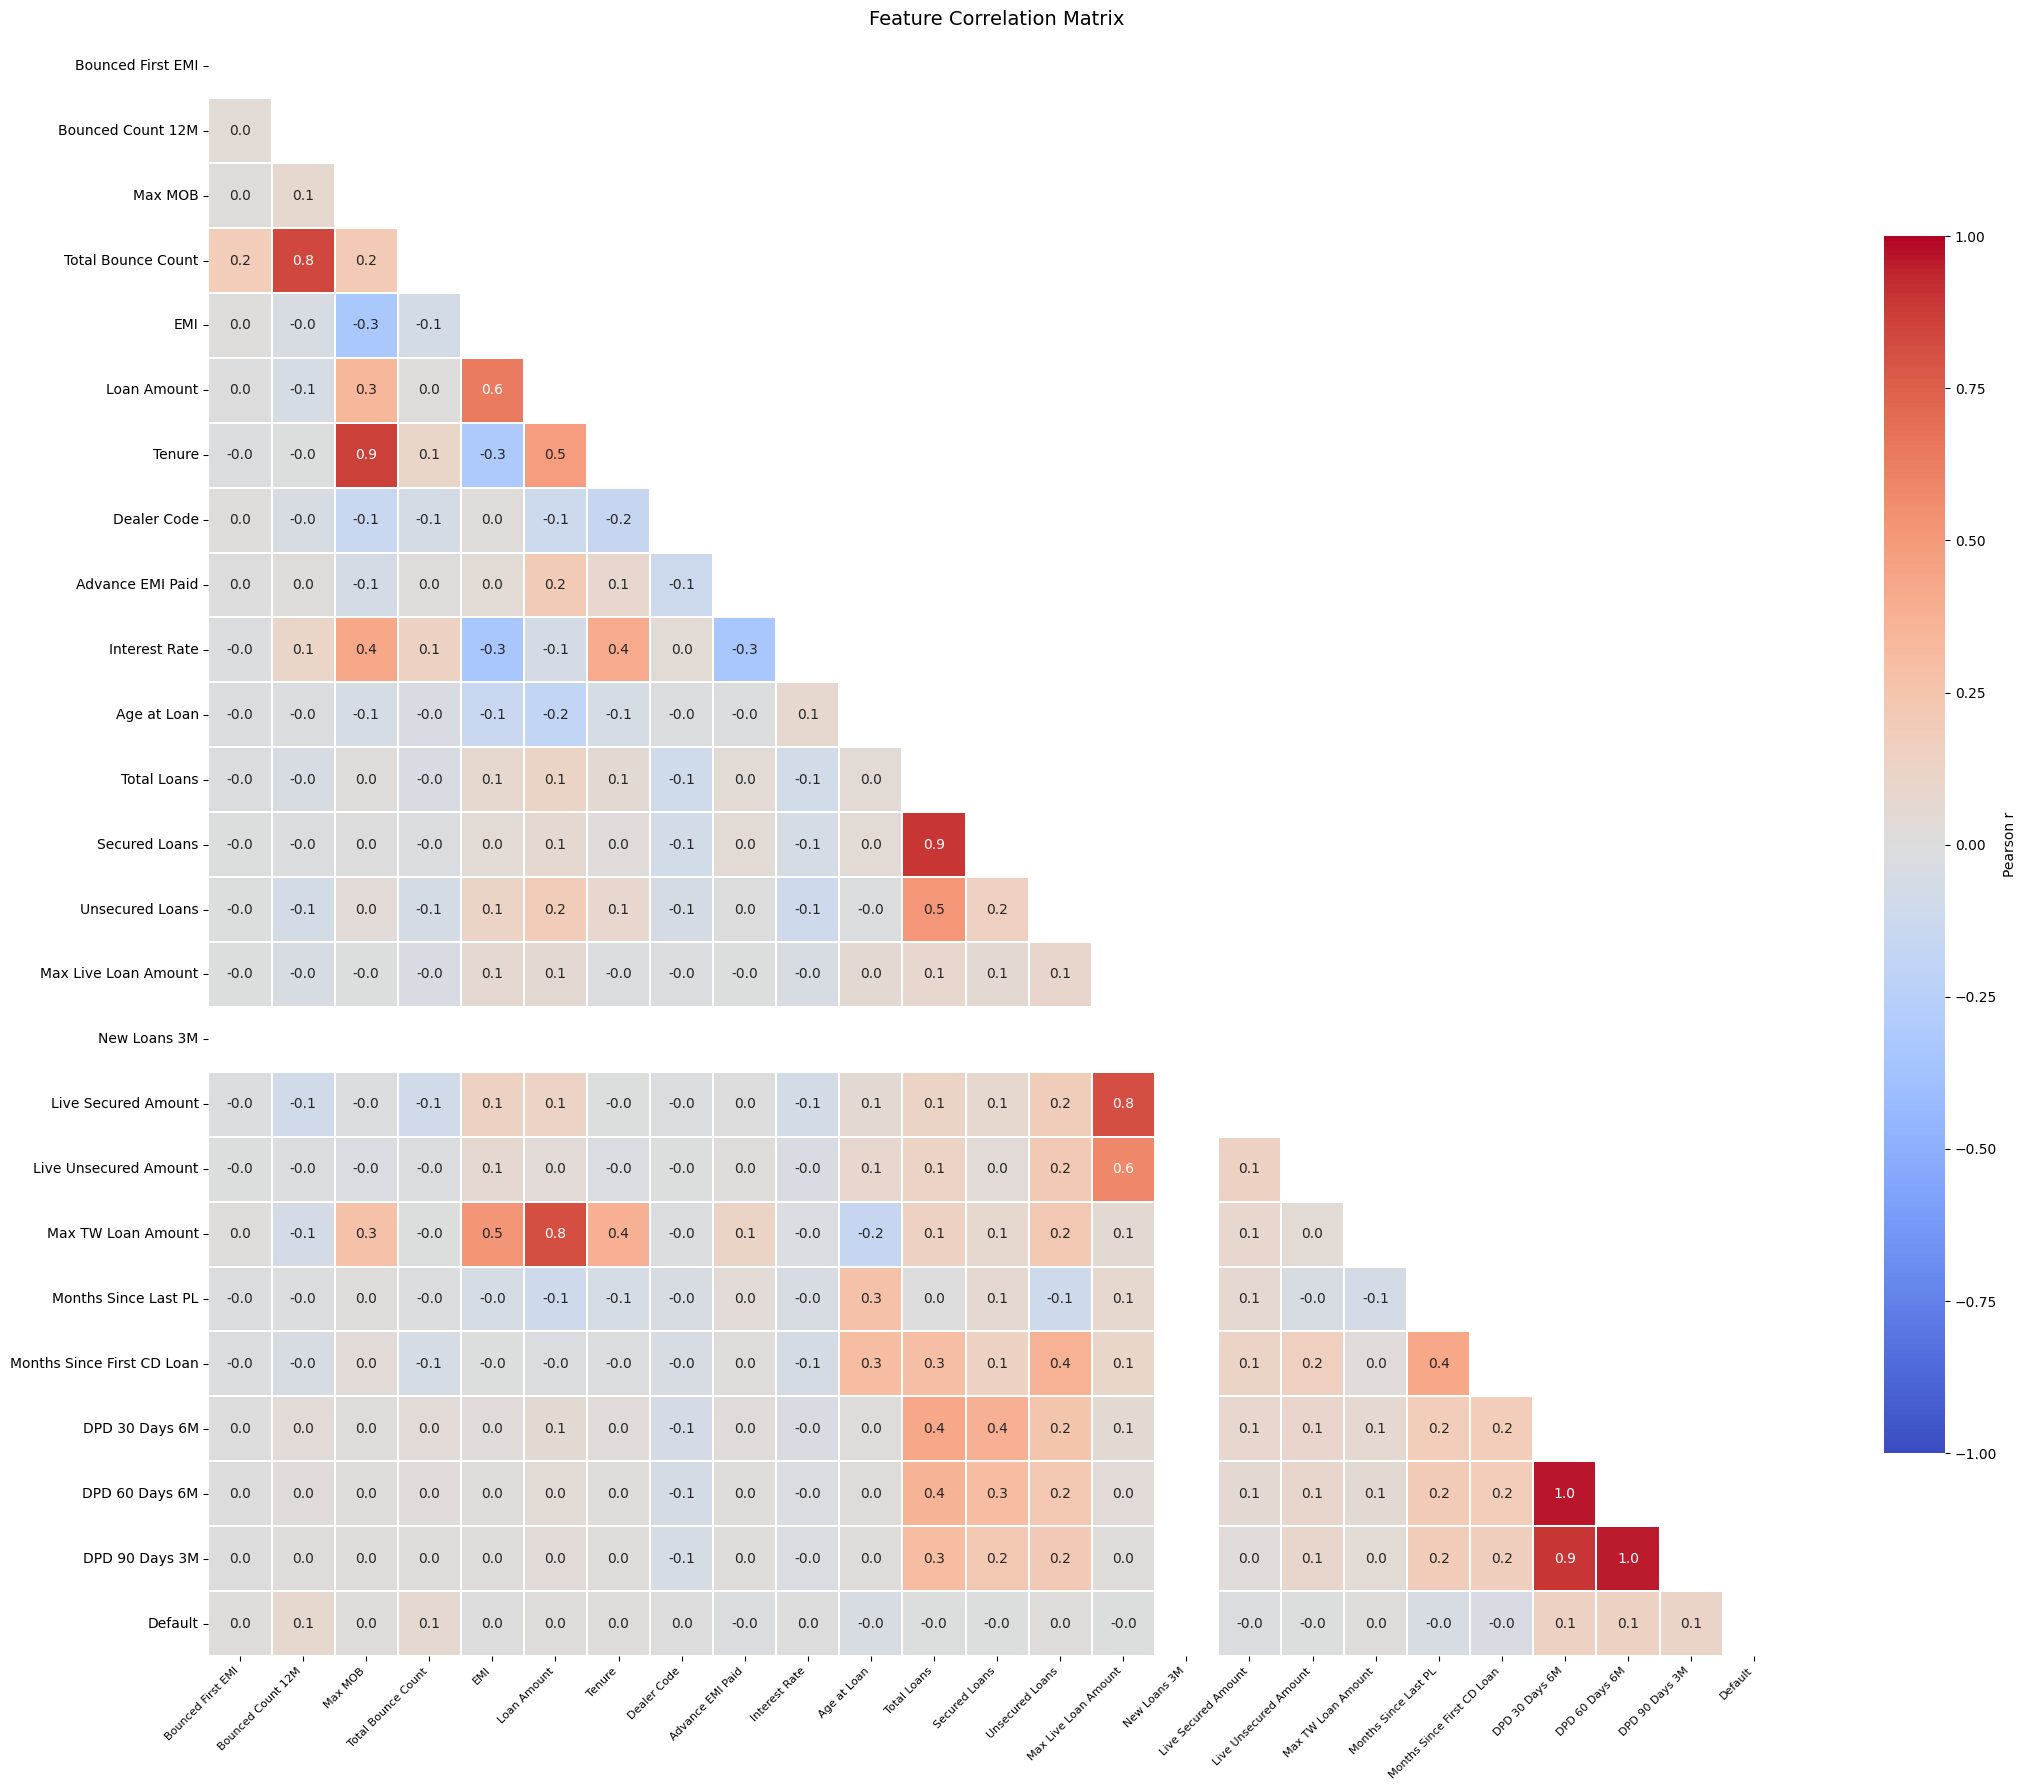

In [69]:
num_df  = Loan.select_dtypes(include=np.number).drop('Customer ID', axis=1)
corrmat = num_df.corr()
mask    = np.triu(np.ones_like(corrmat, dtype=bool))

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corrmat,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.1f',
    linewidths=0.3,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

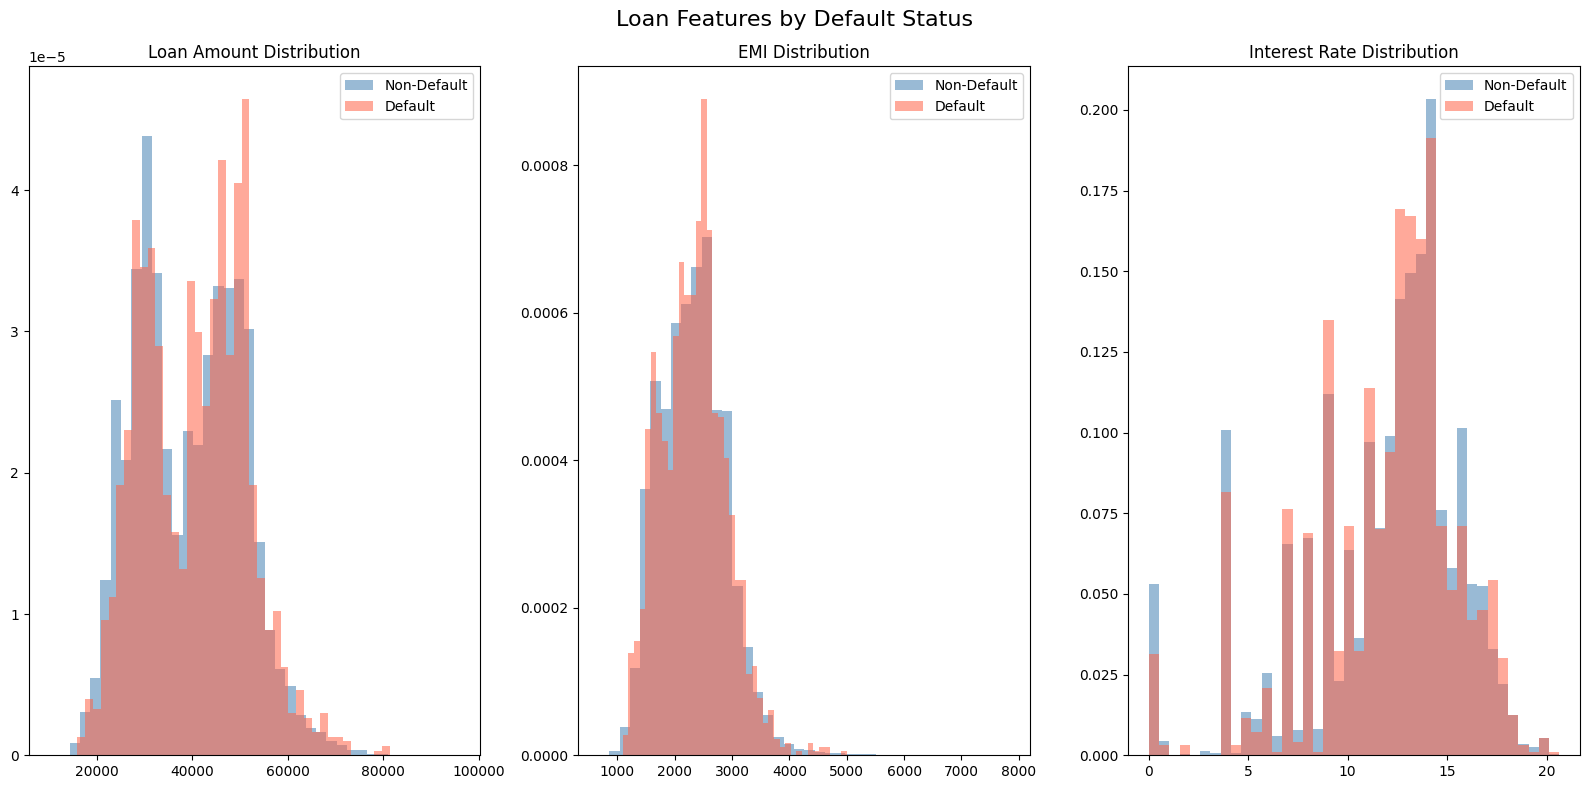

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

loan_features = ['Loan Amount', 'EMI', 'Interest Rate']

for i, col in enumerate(loan_features):
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = Loan[Loan['Default'] == label][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.55, color=color,
                     label='Default' if label == 1 else 'Non-Default',
                     density=True)
    axes[i].set_title(f'{col} Distribution')
    axes[i].legend()

plt.suptitle('Loan Features by Default Status', fontsize=16)
plt.tight_layout()
plt.show()

### Missingness

<Axes: >

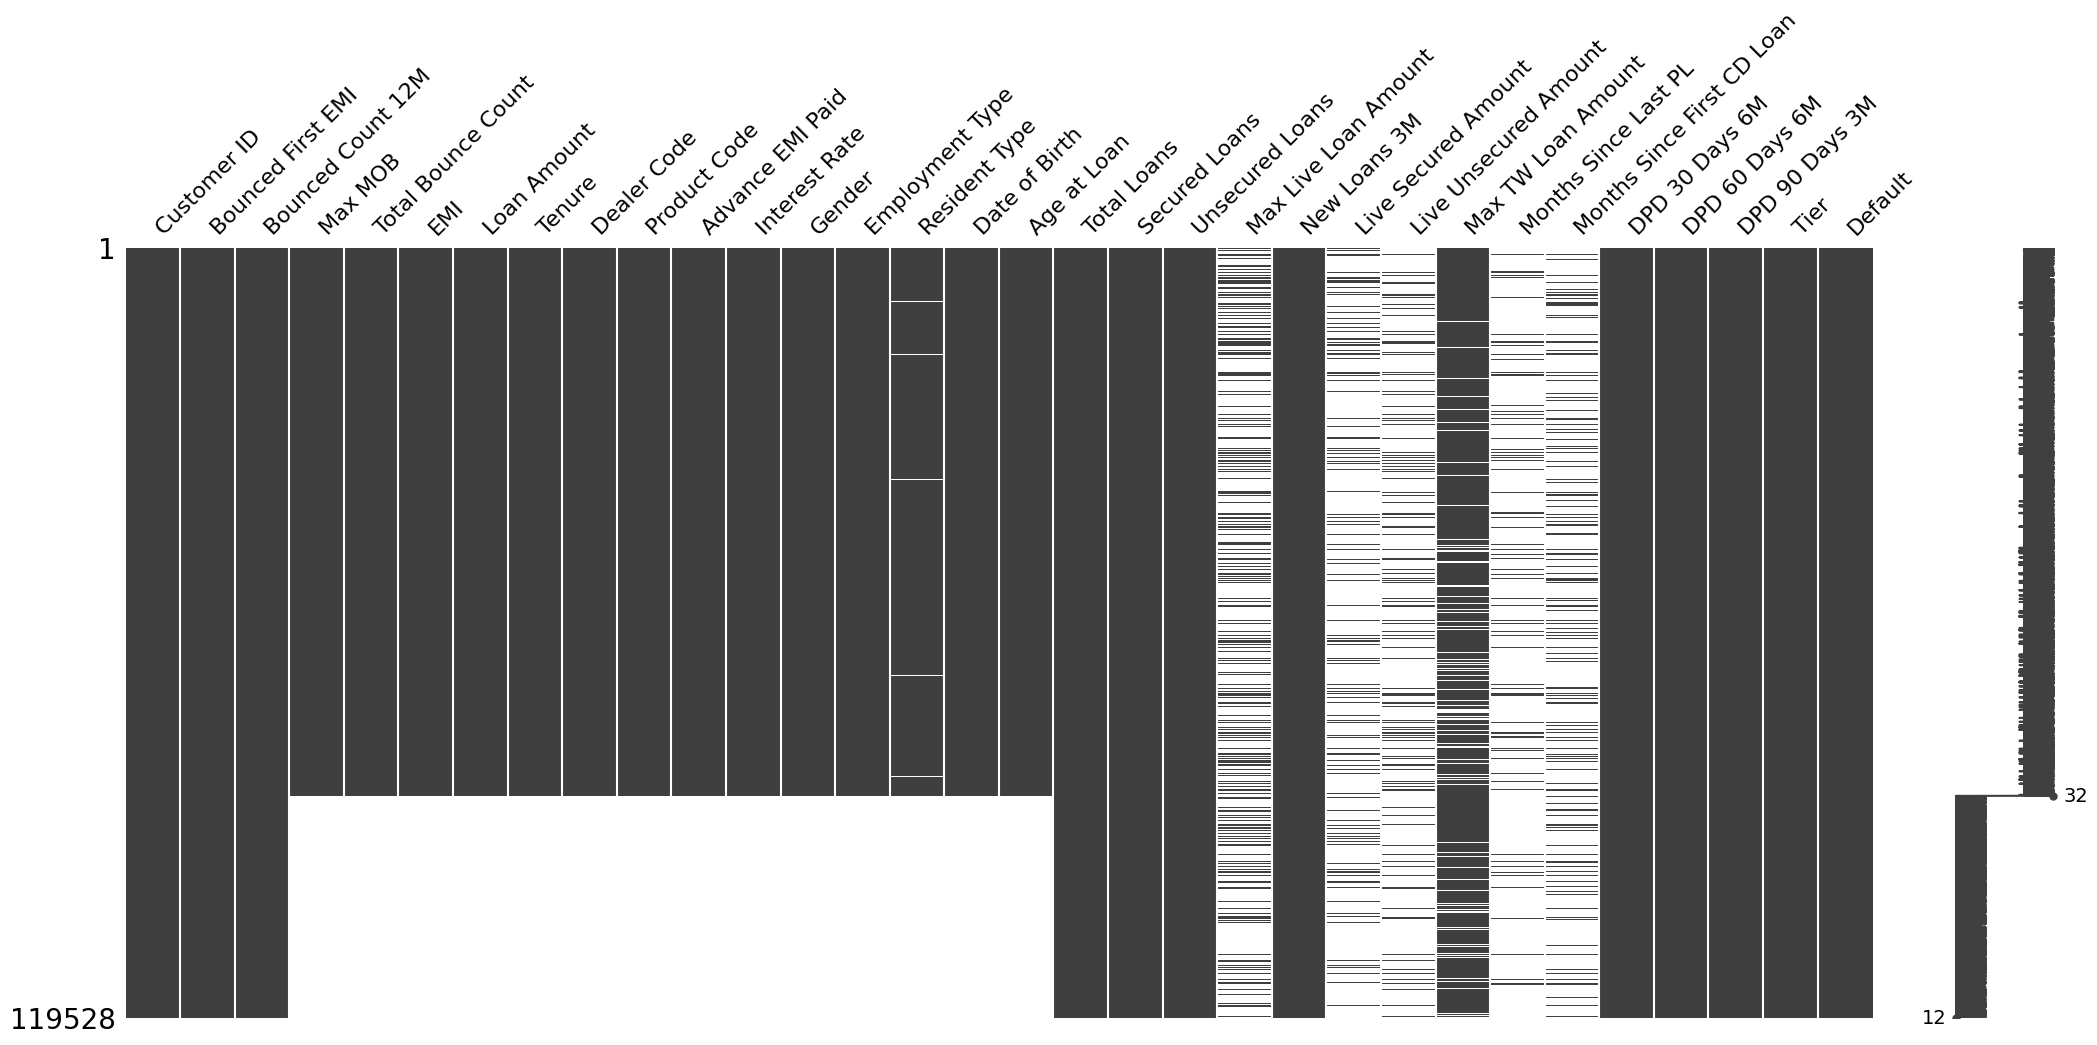

In [47]:
mn.matrix(Loan)

<Axes: >

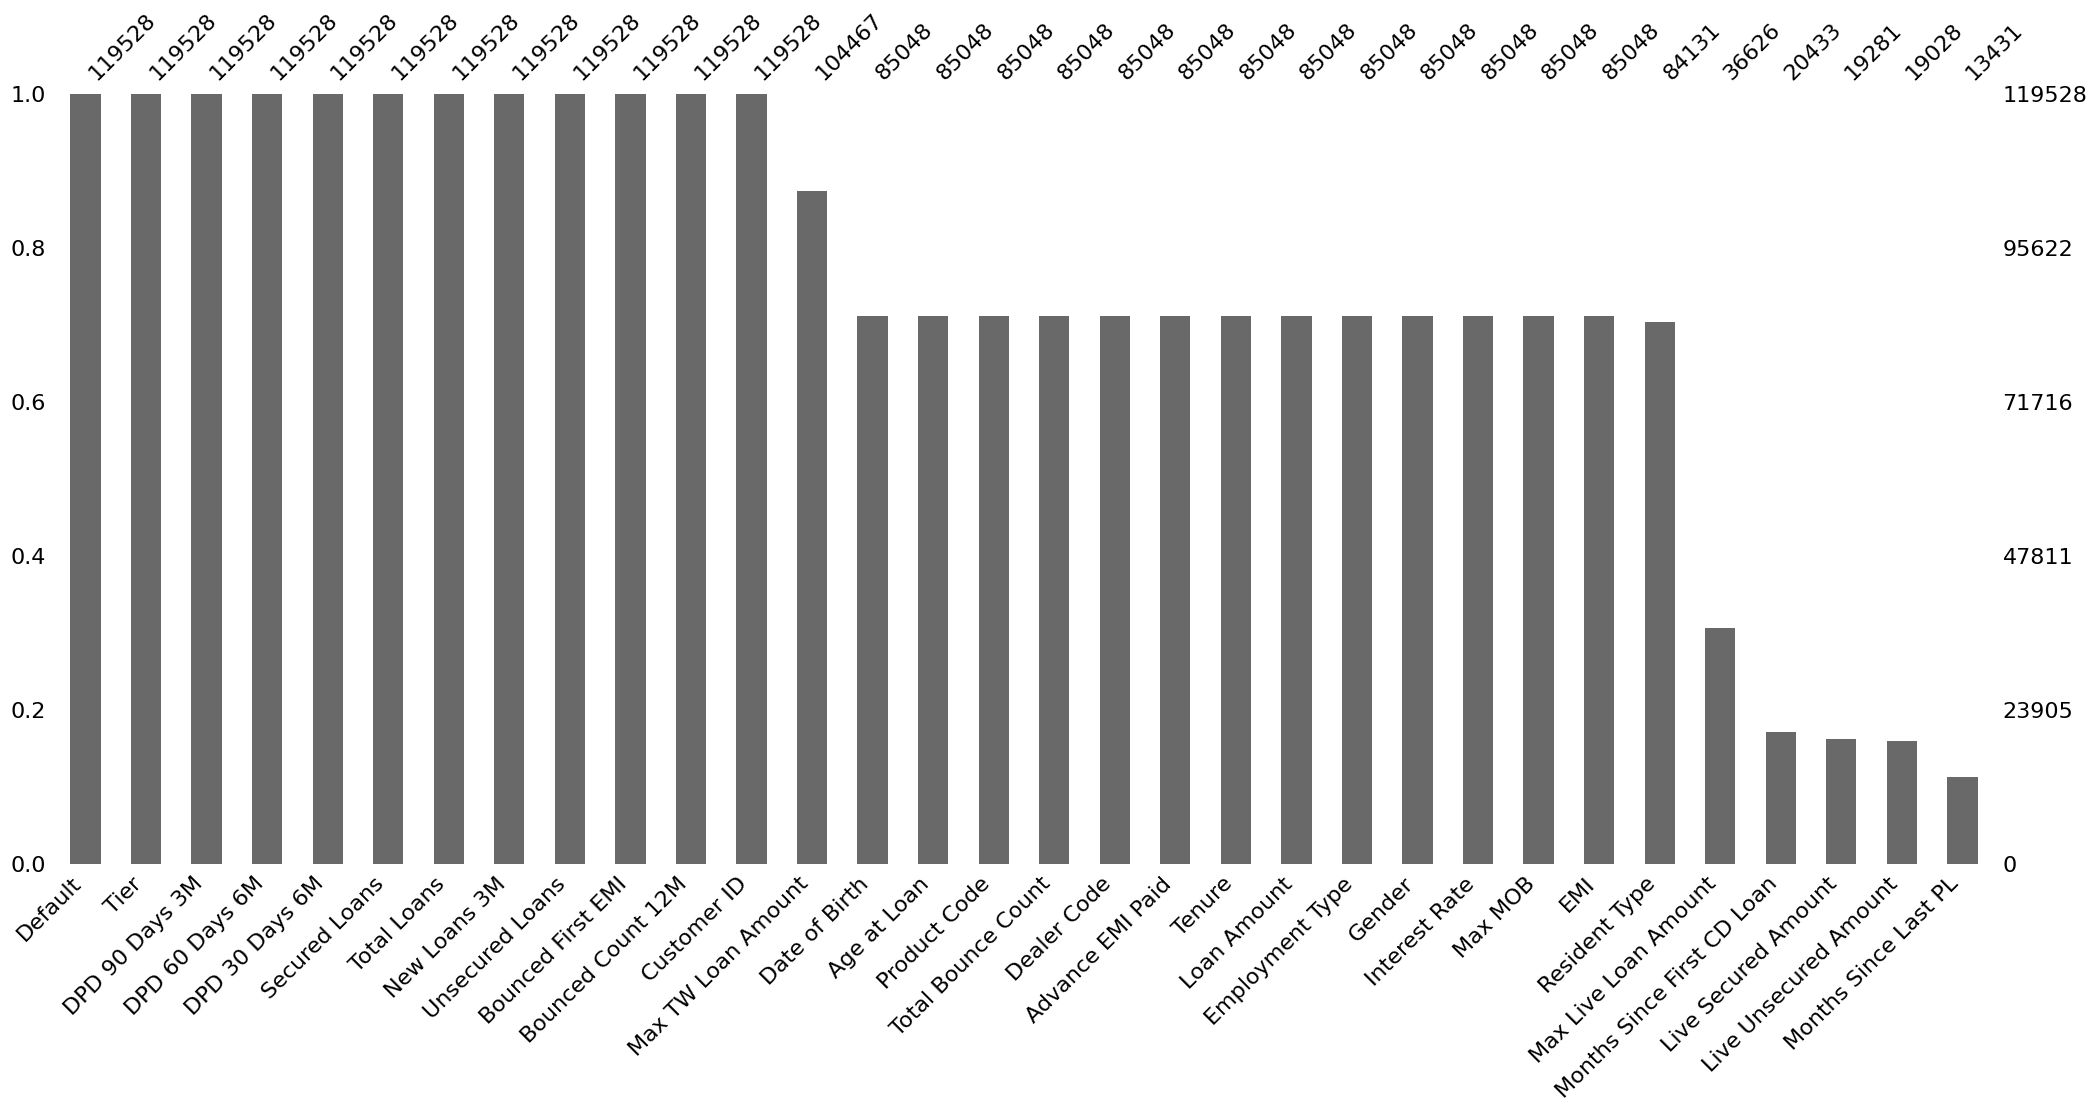

In [48]:
mn.bar(Loan, sort='descending')

<Axes: >

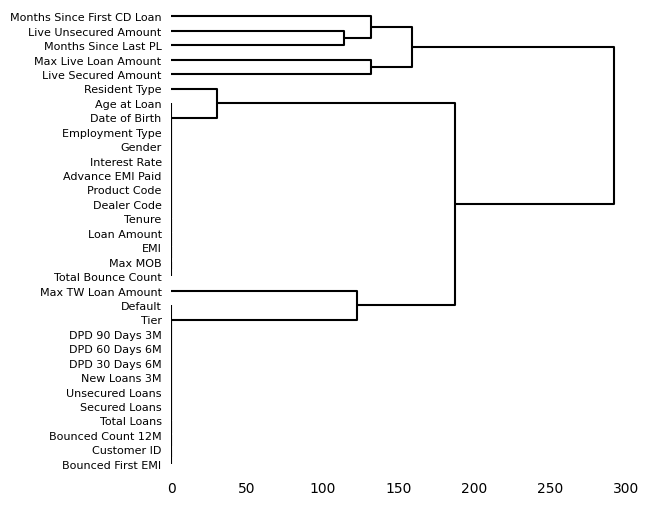

In [51]:
mn.dendrogram(Loan,
              orientation='right',
              figsize=(6, 6),
              fontsize=8)

Conclusion: 

#### Handling Missingness

- Deleting rows with missing values is not possible because dataset would reduce size by ~25%
- 

In [10]:
# check for duplicates
Loan_renamed.duplicated().sum()

np.int64(0)

### Class imbalance

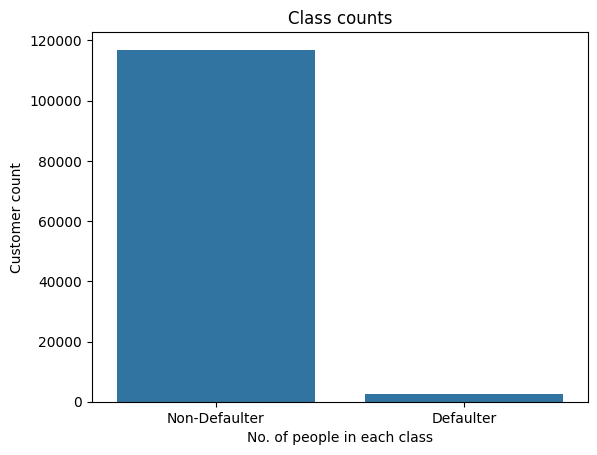

Target variable
0    116914
1      2614
Name: count, dtype: int64


In [ ]:
# distribution of target variable

plt.figure()
sns.countplot(x='Target variable',
              data=Loan_renamed)
plt.xticks((0, 1),
           ["Non-Defaulter", "Defaulter"])
plt.xlabel("No. of people in each class")
# label the number in each class above each bar
plt.ylabel("Customer count")

plt.title("Class counts", y=1)
plt.show()

print(Loan_renamed['Target variable'].value_counts())

#### Distributions

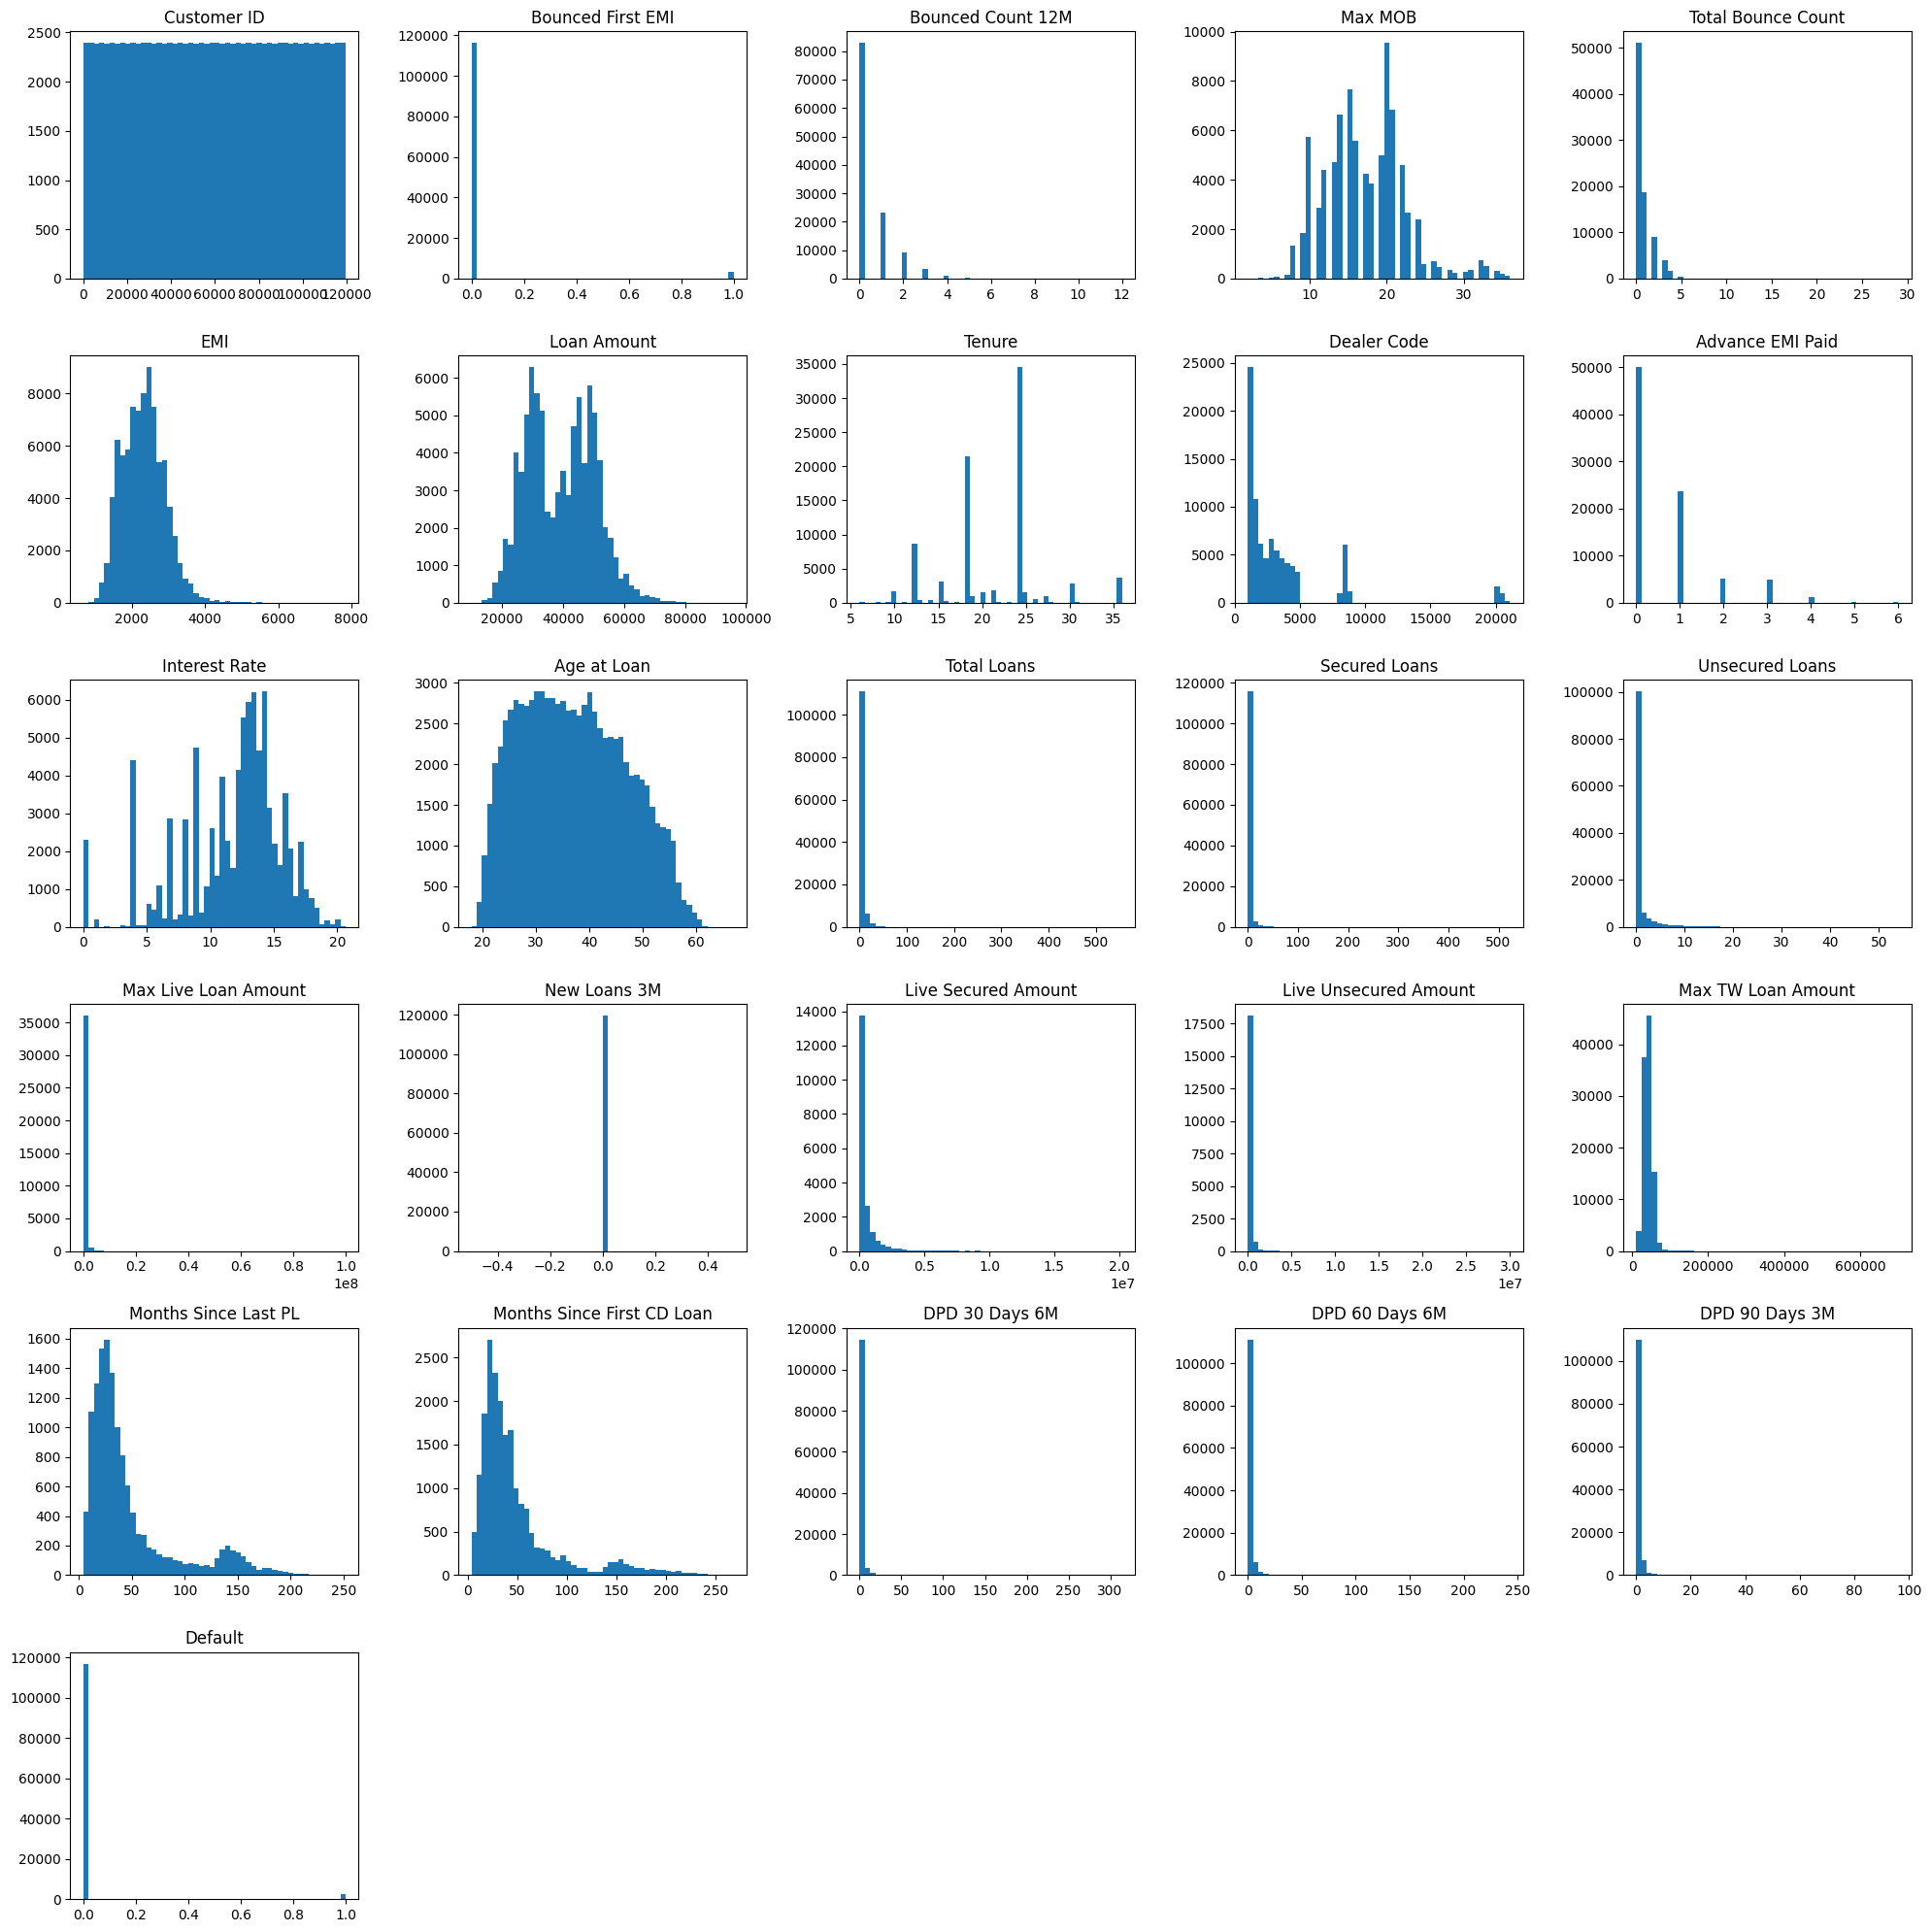

In [72]:
Loan.hist(figsize=(20,20),
                  grid=False,
                  bins=50)
plt.title('Feature Distributions')
plt.tight_layout()
plt.show()

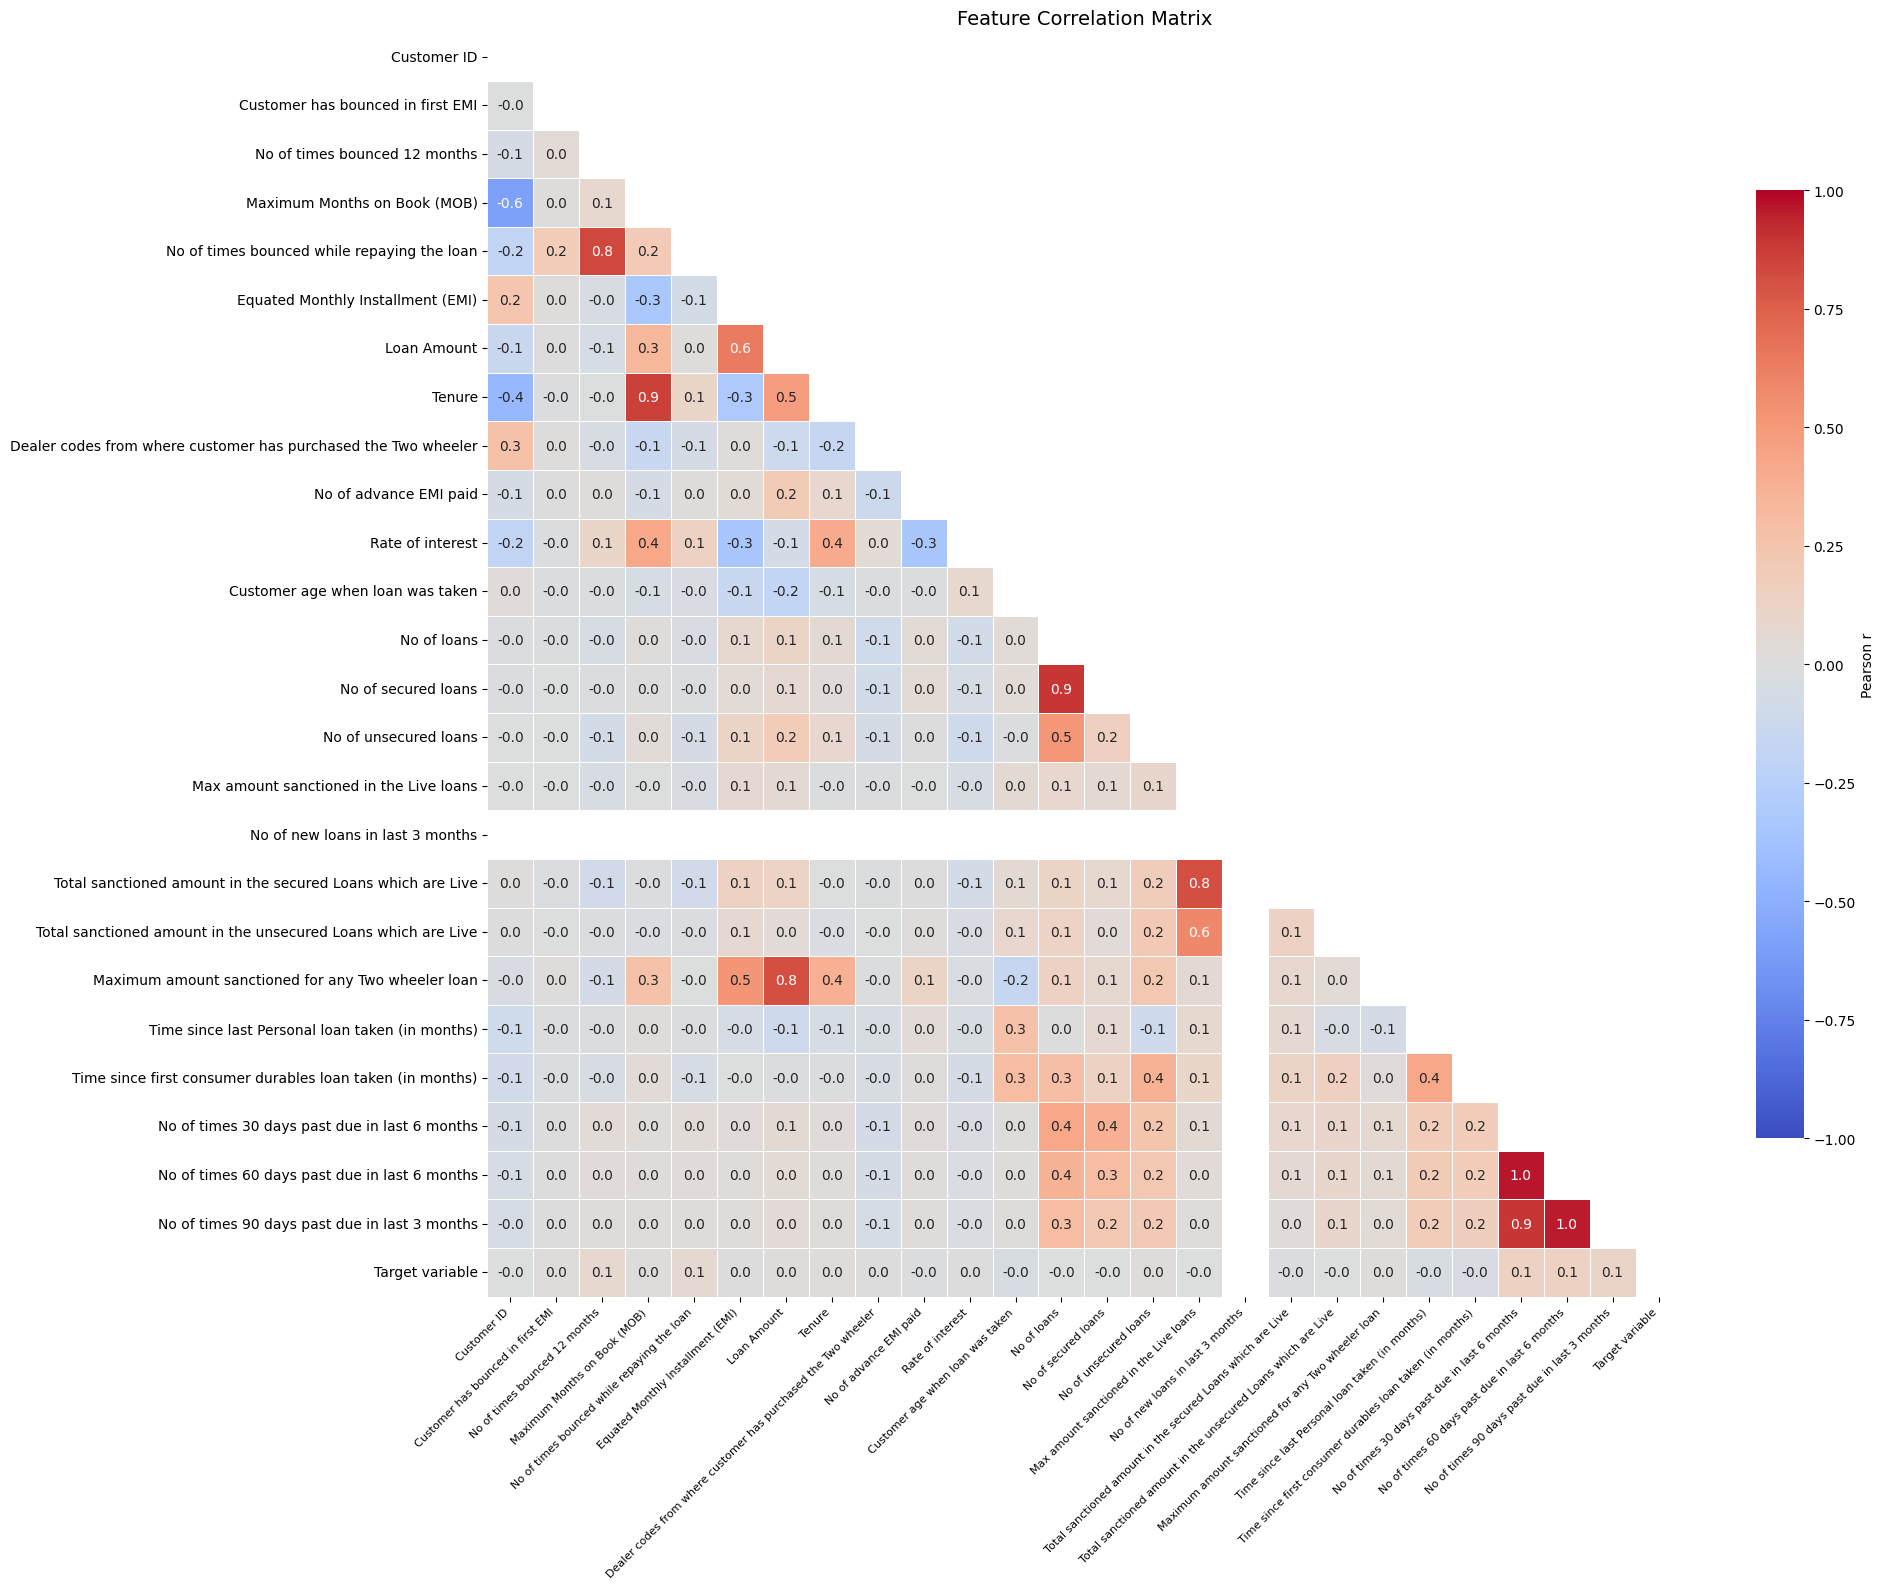

In [ ]:
# correlation matrix for numerical features
numeric_df = Loan_renamed.select_dtypes(include=np.number)

corrmat = numeric_df.corr()
mask = np.triu(np.ones_like(corrmat, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corrmat,
            mask=mask,
            cmap="coolwarm",   
            center=0,          
            vmin=-1,
            vmax=1,
            annot=True,        
            fmt=".1f",         
            linewidths=0.4,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"},
            ax=ax)

ax.set_title("Numerical Features' Correlations",
             fontsize=14,)
plt.xticks(rotation=45,
           ha="right",
           fontsize=8)
plt.yticks()

plt.tight_layout()
plt.show()

The data set is pretty imbalanced as expected where positive examples defualters are significanltly less than 25%. We'll explain in the next section how to handle all of them after giving an overview of ensemble methods.

<font color='white'>For the three plots about LOAN AMOUNT, you could indicate why each is significant and what insights it gives that are different from the other or maybe what it adds on.</font>

### Cleaning & Pre-processing

In [73]:
MISS_THRESHOLD = 0.70

miss_pct = Loan.isnull().mean()
cols_to_drop = miss_pct[miss_pct > MISS_THRESHOLD].index.tolist()

print(f'Columns exceeding {MISS_THRESHOLD*100:.0f}% missing — will be DROPPED:')
for c in cols_to_drop:
    print(f'  {c:40s}  ({miss_pct[c]*100:.1f}% missing)')

Loan_clean = Loan.drop(columns=cols_to_drop)
print(f'\nShape after dropping high-null columns: {Loan_clean.shape}')

Columns exceeding 70% missing — will be DROPPED:
  Live Secured Amount                       (83.9% missing)
  Live Unsecured Amount                     (84.1% missing)
  Months Since Last PL                      (88.8% missing)
  Months Since First CD Loan                (82.9% missing)

Shape after dropping high-null columns: (119528, 28)


In [74]:
Loan_clean = Loan_clean.drop(columns=['Customer ID'])

In [75]:
n_before = len(Loan_clean)
Loan_clean = Loan_clean.drop_duplicates()
n_after = len(Loan_clean)

print(f'Duplicate rows removed: {n_before - n_after}')
print(f'Rows remaining: {n_after:,}')

Duplicate rows removed: 12398
Rows remaining: 107,130


In [76]:
if 'Date of Birth' in Loan_clean.columns:
    Loan_clean = Loan_clean.drop(columns=['Date of Birth'])

In [77]:
num_cols_remaining = Loan_clean.select_dtypes(include=np.number).columns.drop('Default')
cat_cols_remaining = Loan_clean.select_dtypes(include='object').columns

# Median imputation for numerical
for col in num_cols_remaining:
    if Loan_clean[col].isnull().any():
        median_val = Loan_clean[col].median()
        Loan_clean[col] = Loan_clean[col].fillna(median_val)
        print(f'  [NUM] {col}: filled with median = {median_val:.2f}')

# Mode imputation for categorical
for col in cat_cols_remaining:
    if Loan_clean[col].isnull().any():
        mode_val = Loan_clean[col].mode()[0]
        Loan_clean[col] = Loan_clean[col].fillna(mode_val)
        print(f'  [CAT] {col}: filled with mode = "{mode_val}"')

print(f'\nTotal nulls remaining: {Loan_clean.isnull().sum().sum()}')

  [NUM] Max MOB: filled with median = 17.00
  [NUM] Total Bounce Count: filled with median = 0.00
  [NUM] EMI: filled with median = 2320.00
  [NUM] Loan Amount: filled with median = 39703.00
  [NUM] Tenure: filled with median = 24.00
  [NUM] Dealer Code: filled with median = 2307.00
  [NUM] Advance EMI Paid: filled with median = 0.00
  [NUM] Interest Rate: filled with median = 12.60
  [NUM] Age at Loan: filled with median = 36.00
  [NUM] Max Live Loan Amount: filled with median = 95883.00
  [NUM] Max TW Loan Amount: filled with median = 42850.00

Total nulls remaining: 89257


In [79]:
from sklearn.preprocessing import LabelEncoder

In [95]:
cat_cols_now = Loan_clean.select_dtypes(include='str').columns.tolist()
print('Categorical columns to encode:', cat_cols_now)

# Identify binary vs multi-class
binary_cats = [c for c in cat_cols_now if Loan_clean[c].nunique() == 2]
multi_cats  = [c for c in cat_cols_now if Loan_clean[c].nunique() > 2
               and Loan_clean[c].nunique() <= 10]  # OHE only for low cardinality
high_card   = [c for c in cat_cols_now if Loan_clean[c].nunique() > 10]

# Label encode binary columns
le = LabelEncoder()
for col in binary_cats:
    Loan_clean[col] = le.fit_transform(Loan_clean[col].astype(str))
    print(f'  Label encoded: {col}')

# One-hot encode low-cardinality multi-class columns
if multi_cats:
    Loan_clean = pd.get_dummies(Loan_clean, columns=multi_cats, drop_first=True)
    print(f'  One-hot encoded: {multi_cats}')

# Label encode high-cardinality columns (Dealer Code, Product Code)
# These likely encode geographic/product segmentation — tree models can use them.
for col in high_card:
    Loan_clean[col] = le.fit_transform(Loan_clean[col].astype(str))
    print(f'  Label encoded (high-cardinality): {col}')

print(f'\nFinal shape after encoding: {Loan_clean.shape}')

Categorical columns to encode: ['Product Code', 'Gender', 'Employment Type', 'Resident Type', 'Tier']
  Label encoded: Gender
  One-hot encoded: ['Product Code', 'Employment Type', 'Resident Type', 'Tier']

Final shape after encoding: (107130, 35)


### Feature engineering

In [96]:
df = Loan_clean.copy()

# Combined delinquency score — sum of all DPD counts
df['Total DPD'] = df['DPD 30 Days 6M'] + df['DPD 60 Days 6M'] + df['DPD 90 Days 3M']

# Loan burden relative to monthly payment amount
if 'EMI' in df.columns and 'Loan Amount' in df.columns:
    df['Loan to EMI Ratio'] = df['Loan Amount'] / (df['EMI'] + 1)  # +1 avoids division by zero

# Bounce rate: bounces per month of loan book
if 'Total Bounce Count' in df.columns and 'Max MOB' in df.columns:
    df['Bounce Rate'] = df['Total Bounce Count'] / (df['Max MOB'] + 1)

# Loan portfolio diversity
if 'Secured Loans' in df.columns and 'Unsecured Loans' in df.columns:
    df['Unsecured Ratio'] = df['Unsecured Loans'] / (df['Total Loans'] + 1)

print('Engineered features added. New shape:', df.shape)

Engineered features added. New shape: (107130, 39)


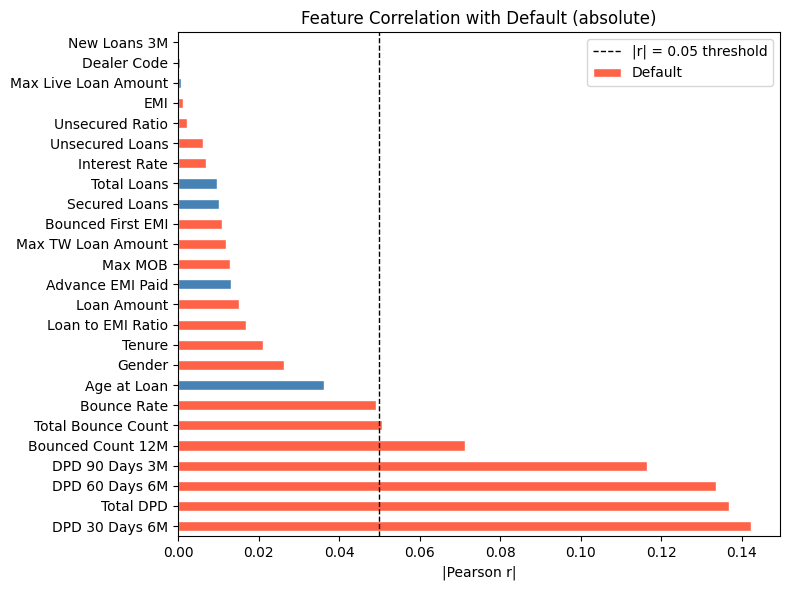

In [97]:
target_corr = df.select_dtypes(include=np.number).corr()['Default'].drop('Default')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
target_corr_sorted.plot(kind='barh', ax=ax,
                        color=['tomato' if v > 0 else 'steelblue'
                               for v in target_corr.loc[target_corr_sorted.index]],
                        edgecolor='white')
ax.set_title('Feature Correlation with Default (absolute)', fontsize=12)
ax.set_xlabel('|Pearson r|')
ax.axvline(0.05, color='black', linestyle='--', linewidth=1, label='|r| = 0.05 threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [98]:
CORR_THRESHOLD = 0.90

feature_df = df.drop(columns=['Default'])
corr_matrix = feature_df.select_dtypes(include=np.number).corr().abs()

# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

print(f'Columns with |r| > {CORR_THRESHOLD} against another feature — candidates for removal:')
print(to_drop_corr)

df = df.drop(columns=to_drop_corr)
print(f'Shape after removing multicollinear features: {df.shape}')

Columns with |r| > 0.9 against another feature — candidates for removal:
['DPD 60 Days 6M', 'DPD 90 Days 3M', 'Total DPD', 'Loan to EMI Ratio', 'Bounce Rate']
Shape after removing multicollinear features: (107130, 34)


## Modelling

### Split & Scale

In [88]:
from sklearn.model_selection import train_test_split

In [99]:
X = df.drop(columns=['Default'])
y = df['Default']
SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y        # preserves class ratio in both splits
)

print(f'Training set : {X_train.shape[0]:,} rows  |  '
      f'Default rate: {y_train.mean()*100:.1f}%')
print(f'Test set     : {X_test.shape[0]:,} rows  |  '
      f'Default rate: {y_test.mean()*100:.1f}%')

Training set : 85,704 rows  |  Default rate: 2.4%
Test set     : 21,426 rows  |  Default rate: 2.4%


In [91]:
from sklearn.preprocessing import RobustScaler

In [93]:
help(RobustScaler)

Help on class RobustScaler in module sklearn.preprocessing._data:

class RobustScaler(sklearn.base.OneToOneFeatureMixin, sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  RobustScaler(
 |      *,
 |      with_centering=True,
 |      with_scaling=True,
 |      quantile_range=(25.0, 75.0),
 |      copy=True,
 |      unit_variance=False
 |  )
 |
 |  Scale features using statistics that are robust to outliers.
 |
 |  This Scaler removes the median and scales the data according to
 |  the quantile range (defaults to IQR: Interquartile Range).
 |  The IQR is the range between the 1st quartile (25th quantile)
 |  and the 3rd quartile (75th quantile).
 |
 |  Centering and scaling happen independently on each feature by
 |  computing the relevant statistics on the samples in the training
 |  set. Median and interquartile range are then stored to be used on
 |  later data using the :meth:`transform` method.
 |
 |  Standardization of a dataset is a common preprocessing for many machi

In [100]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled  = scaler.transform(X_test)       # transform only on test

print('Scaling applied. Training data summary (first 3 features):')
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().iloc[:, :3]

Scaling applied. Training data summary (first 3 features):


,Bounced First EMI,Bounced Count 12M,Max MOB
count,85704.000000,85704.000000,85704.000000
mean,0.030430,0.489429,0.027682
std,0.171769,0.872784,0.771603
min,0.000000,0.000000,-2.500000
25%,0.000000,0.000000,-0.500000
50%,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.500000
max,1.000000,12.000000,3.166667


In [101]:
from imblearn.over_sampling import SMOTE

In [102]:
print('Class distribution in training set:')
print(y_train.value_counts())

# SMOTE: apply only to training data — NEVER to test data
# (Applying SMOTE to test data would create artificially easy test examples.)
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('\nClass distribution after SMOTE:')
print(pd.Series(y_train_smote).value_counts())

Class distribution in training set:
Default
0    83684
1     2020
Name: count, dtype: Int64

Class distribution after SMOTE:
Default
0    83684
1    83684
Name: count, dtype: Int64


In [122]:
#   We focus on:
#   - ROC-AUC    : separability between classes regardless of threshold
#   - Recall     : what fraction of actual defaulters did we catch? (key for banks)
#   - Precision  : of predicted defaulters, how many were real? (cost of false alarms)
#   - F1         : harmonic mean of precision and recall
#   - PR-AUC     : better than ROC-AUC for highly imbalanced datasets

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [113]:
# With 97.8% non-defaults, accuracy is misleading.

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    roc_auc = roc_auc_score(y_te, y_proba)
    pr_auc  = average_precision_score(y_te, y_proba)
    report  = classification_report(y_te, y_pred, output_dict=True)
    
    results = {
        'Model'    : name,
        'ROC-AUC'  : round(roc_auc, 4),
        'PR-AUC'   : round(pr_auc, 4),
        'Recall(1)'    : round(report.get('1', {}).get('recall', 0.0), 4),
        'Precision(1)' : round(report.get('1', {}).get('precision', 0.0), 4),
        'F1(1)'        : round(report.get('1', {}).get('f1-score', 0.0), 4),
        'Accuracy' : round(report.get('accuracy', 0.0), 4),
    }
    return results, model, y_proba

results_log = []   # will store one dict per model run

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [115]:
# Logistic regression

# --- Strategy A: Class Weights ---
lr_cw = LogisticRegression(C=0.1,
                           class_weight='balanced',
                            max_iter=5000,
                            solver = 'saga',
                            random_state=SEED)
r, _, _ = evaluate_model('LR — Class Weights',
                          lr_cw,
                          X_train_scaled,
                          y_train,
                          X_test_scaled,
                          y_test)
results_log.append(r)

# --- Strategy B: SMOTE ---
lr_sm = LogisticRegression(C=0.1, max_iter=5000, random_state=SEED)
r, _, _ = evaluate_model('LR — SMOTE',
                          lr_sm, X_train_smote, y_train_smote,
                          X_test_scaled, y_test)
results_log.append(r)

print('Logistic Regression — done.')

d:\2-zindua\04-machine-learning-1\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression — done.


In [117]:
# Random Forest

# --- Strategy A: Class Weights ---
rf_cw = RandomForestClassifier(n_estimators=300, max_depth=10,
                                class_weight='balanced',
                                random_state=SEED, n_jobs=-1)
r, rf_cw_fitted, _ = evaluate_model('Random Forest — Class Weights',
                                    rf_cw, X_train_scaled, y_train,
                                    X_test_scaled, y_test)
results_log.append(r)

# --- Strategy B: SMOTE ---
rf_sm = RandomForestClassifier(n_estimators=300, max_depth=10,
                                random_state=SEED, n_jobs=-1)
r, rf_sm_fitted, _ = evaluate_model('Random Forest — SMOTE',
                                    rf_sm, X_train_smote, y_train_smote,
                                    X_test_scaled, y_test)
results_log.append(r)

print('Random Forest — done.')

Random Forest — done.


In [124]:
results_df = pd.DataFrame(results_log).set_index('Model').sort_values('ROC-AUC', ascending=False)

results_df

,ROC-AUC,PR-AUC,Recall(1),Precision(1),F1(1),Accuracy
Model,,,,,,
Random Forest — Class Weights,0.8420,0.1826,0.0,0.0,0.0,0.8880
Random Forest — SMOTE,0.8267,0.1519,0.0,0.0,0.0,0.9394
LR — SMOTE,0.8227,0.1179,0.0,0.0,0.0,0.7941
LR — Class Weights,0.6128,0.0338,0.0,0.0,0.0,0.3990


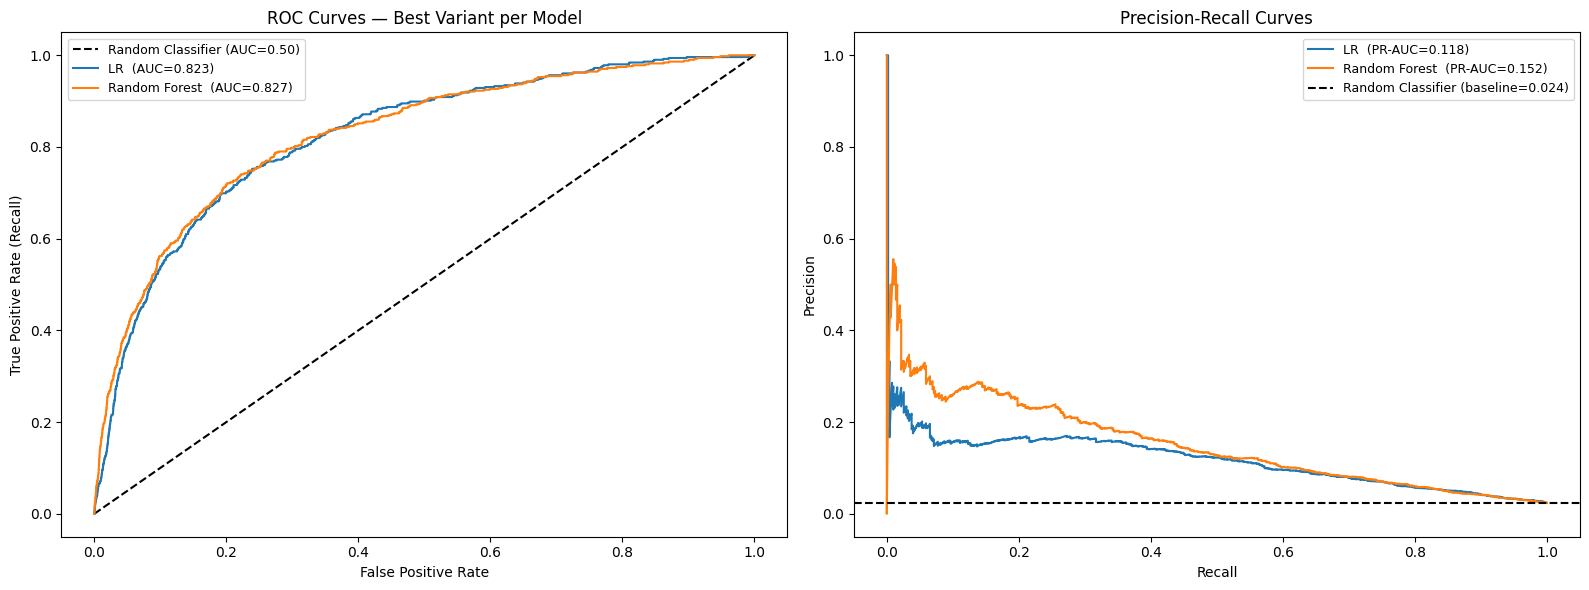

In [123]:
# Collect best variant (SMOTE) for each model for the ROC plot
roc_models = [
    ('LR', lr_sm, X_train_smote, y_train_smote),
    ('Random Forest', rf_sm_fitted, None, None),    # already fitted
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.50)')
for label, model, Xtr, ytr in roc_models:
    if Xtr is not None:
        model.fit(Xtr, ytr)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{label}  (AUC={auc:.3f})')

axes[0].set_title('ROC Curves — Best Variant per Model')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(fontsize=9)

# Precision-Recall Curve
for label, model, _, _ in roc_models:
    proba = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{label}  (PR-AUC={pr_auc:.3f})')

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--',
                label=f'Random Classifier (baseline={baseline:.3f})')
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()